<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Car_plate_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Car plate detection**

---

## **Introduction**

Beside human body objects that we have done in previous tutorials ([face detection](https://github.com/harishmuh/Computer_Vision_study/blob/main/Image_preprocessing_IX.ipynb) and [face, nose, eyes detection from video](https://colab.research.google.com/drive/1GsbMiadXI0yBOCxD_0Z2j7Vtm2avPSeV?usp=sharing)), the haar-like algorithms also being developed to detect car plat numbers. In this tutorial, we will try to implement the object detection algorithm for detecting digits in non-human object like car plat numbers. We will cover the steps from initial setup to detecting, blurring, and finally extracting plate numbers from images.

**Initial setup**

Firstly, we need to install an additional library for object detection.

In [1]:
# Initial setup
# Installing additional library for object detection and reading
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 13.0 MB/s eta 0:00:00


In [2]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

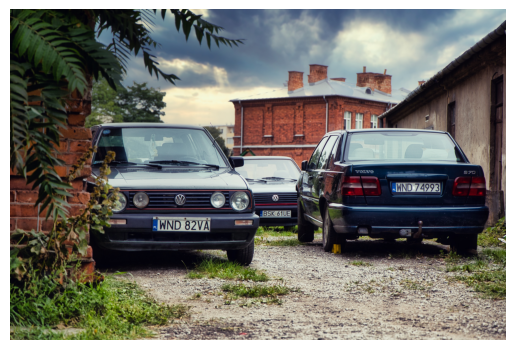

In [3]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/car_plate.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

In [4]:
# Downloading 'haarcascades' russian plate
import os
import urllib.request

# Create the haarcascades directory if it doesn't exist
haarcascade_dir = 'haarcascades'
if not os.path.exists(haarcascade_dir):
    os.makedirs(haarcascade_dir)

# URL of the haarcascade XML file
cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_russian_plate_number.xml'
cascade_filename = os.path.join(haarcascade_dir, 'haarcascade_russian_plate_number.xml')

# Download the file
if not os.path.exists(cascade_filename):
    print(f"Downloading {cascade_filename}...")
    urllib.request.urlretrieve(cascade_url, cascade_filename)
    print("Download complete.")
else:
    print(f"{cascade_filename} already exists. Skipping download.")

Download complete.


## **Car Plate detection**

After the input image has been ready, we need to obtain the the Haar cascade (for european or russian plate numbers) XML file and place it on a directory.

In [5]:
# Preparing the model
plat_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_russian_plate_number.xml')

In [6]:
# Adjusting parameters

# Preparing output image
plat_img = input_img.copy()

print('Image shape:', plat_img.shape)

# Adjusting parameters for object detection
plat_detection = plat_cascade.detectMultiScale(plat_img,
                                              scaleFactor=1.08,
                                              minNeighbors=15)

Image shape: (3367, 5051, 3)


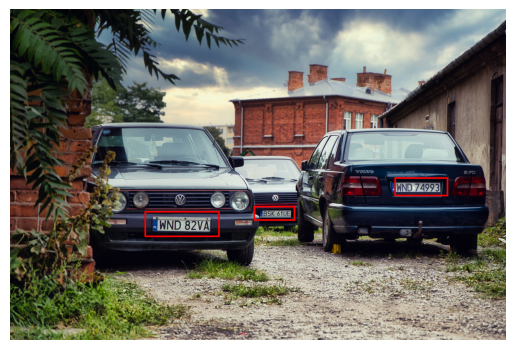

In [7]:
# Adding bounding box to the detected area
for(x,y,w,h) in plat_detection:
    cv2.rectangle(plat_img, (x,y), (x+w, y+h), (255), 15)

# Displaying the output image
plt.axis('off')
plt.imshow(plat_img, cmap='gray')
plt.show()

Let's try another picture!

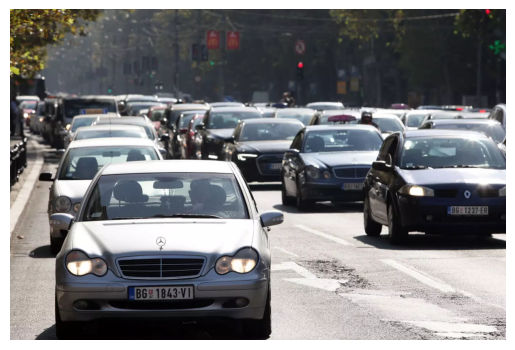

In [8]:
# Attaching the second example

# Image link
url1 = 'https://vreme.com/wp-content/uploads/2024/11/Saobracaj_2023_03-1.webp'

# Download and open the image
with urllib.request.urlopen(url1) as f:
    input_img_new = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img_new = np.array(input_img_new)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_new, cmap='gray')
plt.show()

In [19]:
# Preparing output image and adjusting parameters

# Preparing output image
plat_img_4 = input_img_new.copy()

print('Image shape', plat_img_4.shape)

# Adjusting parameters for object detection
plat_detection_4 = plat_cascade.detectMultiScale(plat_img_4, scaleFactor=1.08,
                                              minNeighbors=15)

Image shape (960, 1440, 3)


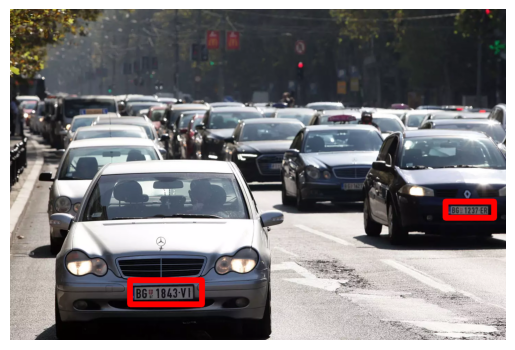

In [20]:
# Adding bounding box to the detected area
for(x,y,w,h) in plat_detection_4:
    cv2.rectangle(plat_img_4, (x,y), (x+w, y+h), (255), 15)

# Displaying the output image
plt.axis('off')
plt.imshow(plat_img_4, cmap='gray')
plt.show()

## **Car plate detection and blurring**

In [11]:
# Preparing output image and adjusting parameters

# Preparing output image
plat_img_2 = input_img.copy()

# Adjusting parameters for object detection
plat_detection_2 = plat_cascade.detectMultiScale(plat_img_2,
                                              minNeighbors=15)

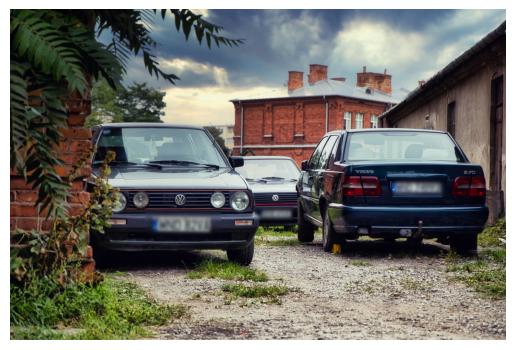

In [12]:
# Implementation
# Detecting the region of interest and applying Gaussian Blurr
for(x,y,w,h) in plat_detection_2:
    target = plat_img_2[y:y+h, x:x+w]
    target = cv2.GaussianBlur(target, (101,101), 0)
    plat_img_2[y:y+h, x:x+w] = target


# Displaying the output image
plt.axis('off')
plt.imshow(plat_img_2, cmap='gray')
plt.show()

## **Extracting plat numbers**

In order to extract plate numbers, we will crop the detected area first. After that, we will extract alphabets and numbers using easyocr library that will display digits based on the reading process.

In [13]:
# Preparing output image and adjusting parameters

# Preparing output image
plat_img_3 = input_img.copy()

print('Image shape', plat_img_3.shape)

# Adjusting parameters for object detection
plat_detection_3 = plat_cascade.detectMultiScale(plat_img_3,
                                              minNeighbors=15)

Image shape (3367, 5051, 3)


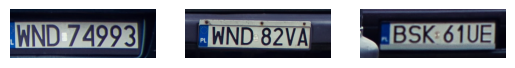

In [14]:
# Cropping plat image
cropped_plate = []
for(x,y,w,h) in plat_detection_3:
    cropped_plate.append(plat_img_3[y:y+h, x:x+w])

# Displaying the cropped plat
for i, plate in enumerate(cropped_plate):
    plt.subplot(1, len(cropped_plate), i + 1)  # Combine subplot creation and indexing
    plt.axis('off')
    plt.imshow(plate, cmap='gray')

plt.show()

We have successfully detected and cropped the car plat. Now, we will extract the digits.

In [15]:
# Extracting plat number

import easyocr
reader = easyocr.Reader(['en'])

for plate in cropped_plate:

    th, plate = cv2.threshold(plate, 100, 255, cv2.THRESH_BINARY)
    plate = cv2.blur(plate, (3,3))

    # Extracting numbers from the car plate
    result = reader.readtext(plate)

    # Displaying the extracted numbers
    for (bbox, text, prob) in result:
    	print(f'Text: {text}, Probability: {prob}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text: WND Z4993, Probability: 0.7003856851456401
Text: PL, Probability: 0.9826804331567626
Text: WND 82VA, Probability: 0.9143936844232692
Text: BSK 61UE], Probability: 0.5158091267819168


It turns out we have correctly extract the first and second plate numbers, but less correct for the third plate. The model also detect the 'PL' text which represents the country origin of Poland. This experiment display that there are challenges and limitation when applying Haar cascade models.

## **Conclusion**

In this notebook, we successfully implemented car plate detection, blurring, and text extraction using Haar cascades and EasyOCR. We demonstrated the process from setting up the environment, downloading the necessary cascade file, detecting plate regions, applying a blur filter for privacy, and finally extracting the text from the plate numbers. While the detection and blurring worked effectively, the OCR accuracy varied, highlighting the challenges of text recognition in real-world image conditions. Future improvements could involve using more advanced OCR models or pre-processing techniques to enhance recognition rates.